# 0. 환경설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 1. 개요

## 1. 기본정보

In [3]:
# 1-1 CSV 파일 불러오기

df = pd.read_csv("../../CSV_files/studentAssessment.csv")
df.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [4]:
# 1-2 정보

df.info()

# ? 결측치(score) 173건은 왜 있는가?
# ? id_assessment, id_student를 식별자로 봐도 되는가?

<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


In [5]:
# 1-3 기술통계
# id_assessment, id_student는 식별자성 외래키라 여기선 제외하고 봐야함

df.describe()

# score는 0~100 범위, 평균 75.8 / 중앙값 80 → 평균보다 중앙값이 높음(왼쪽 꼬리, 저점수 방향 치우침)
# date_submitted는 -11~608일 범위. 마감일(0일 기준) 이전 음수값이 존재 -> 왜 마이너스인지 확인 필요

,id_assessment,id_student,date_submitted,is_banked,score
count,173912.000000,1.739120e+05,173912.000000,173912.000000,173739.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977,75.799573
std,8829.784254,5.523952e+05,71.484148,0.104194,18.798107
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000,65.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000,80.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000


In [6]:
# 1-4 결측치 위치 조회
# Q 질문 도출 : score 결측(173건)은 제출은 됐는데 채점이 안 된 것인가?

df[df['score'].isna()].head(10)

,id_assessment,id_student,date_submitted,is_banked,score
215,1752,721259,22,0,NaN
937,1754,260355,127,0,NaN
2364,1760,2606802,180,0,NaN
3358,14984,186780,77,0,NaN
3914,14984,531205,26,0,NaN
3943,14984,534151,7,0,NaN
4206,14984,549713,84,0,NaN
4311,14984,554393,55,0,NaN
4753,14985,186780,77,0,NaN
5722,14986,33666,117,0,NaN


In [7]:
print('결측 score 건수:', df['score'].isna().sum())
print(df[df['score'].isna()]['is_banked'].value_counts())

# ! 결측 173건 중 172건은 is_banked=0(정상 제출) → 이월 데이터 문제가 아니라 단순 채점 누락/미채점 가능성이 큼

결측 score 건수: 173
is_banked
0    172
1      1
Name: count, dtype: int64


## 2. 속성별 정보

In [8]:
# 2-1 속성 종류

df.columns

Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], dtype='str')

In [9]:
# 2-2 속성 데이터 타입

df.dtypes

id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object

In [10]:
# 2-3 고유값 개수

df.nunique()

# id_assessment      188   → 전체 행수(173,912)보다 훨씬 적지만, 실제로는 assessments.csv의 평가를 가리키는 외래키 → 식별자 아님, 그룹변수로만 참고
# id_student       23,369  → 학생별로 여러 건 제출 → 외래키
# date_submitted     312   → 값이 많고 연속적 → 수치형
# is_banked            2   → 값이 2개뿐 → 범주형(이진)
# score              101   → 0~100 사이 점수, 연속적 → 수치형

id_assessment       188
id_student        23369
date_submitted      312
is_banked             2
score               101
dtype: int64

In [11]:
# 2-4 식별자(복합키) 무결성 체크
# id_assessment 단독으로는 식별자가 아니지만, (id_assessment, id_student) 조합은 유일해야 정상

dup = df.duplicated(subset=['id_assessment', 'id_student'])
print('중복 조합 개수:', dup.sum())

# ! 한 학생이 같은 평가를 두 번 제출한 케이스는 없음 → (id_assessment, id_student)가 사실상 행 식별자 역할을 함

중복 조합 개수: 0


### studentAssessment.csv 속성 정리

| 컬럼명 | 타입 | 설명 | 값 예시 / 범위 | 결측치 |
|---|---|---|---|---|
| id_assessment | int64 | 평가 ID (assessments.csv 외래키) | 188개 고유값 (전체 206개 평가 중 일부) | 0 |
| id_student | int64 | 학생 ID (studentInfo.csv 외래키) | 23,369명, 1인당 1~28건 제출 | 0 |
| date_submitted | int64 | 제출일 (학기 시작일 0 기준 일수) | -11 ~ 608일 | 0 |
| is_banked | int64 | 이전 학기 결과를 이월받았는지 여부(1=이월) | 0 / 1 (1은 전체의 1.1%) | 0 |
| score | float64 | 채점 점수 | 0 ~ 100점 | 173건 (0.1%) |

**행/열 구조**: 173,912 rows × 5 columns

**참고**
- id_assessment, id_student는 둘 다 식별자가 아니라 외래키이며, (id_assessment, id_student) 조합만 유일함
- is_banked=1인 건은 이번 학기에 실제로 응시하지 않고 이전 학기 점수를 그대로 이월받은 경우 → 제출 건수 집계 시 주의 필요
- date_submitted 음수값(2,057건) 중 1,909건이 is_banked=1과 겹침 → 실제 조기 제출이라기보다 이월 데이터의 표기 특성일 가능성

# 2. 그래프 및 구조

## 1. 범주형 그래프

In [12]:
# 0. 범주형/수치형 구분
# is_banked            : 고유값 2개 → 범주형(이진)
# id_assessment/id_student : 외래키(고유값 많음) → 정식 범주형 그래프 대상은 아니지만 참고용으로 상위/하위만 시각화
# date_submitted, score    : 연속형 → 수치형

cat_cols = ['is_banked']
num_cols = ['date_submitted', 'score']
print('범주형:', cat_cols)
print('수치형:', num_cols)

범주형: ['is_banked']
수치형: ['date_submitted', 'score']


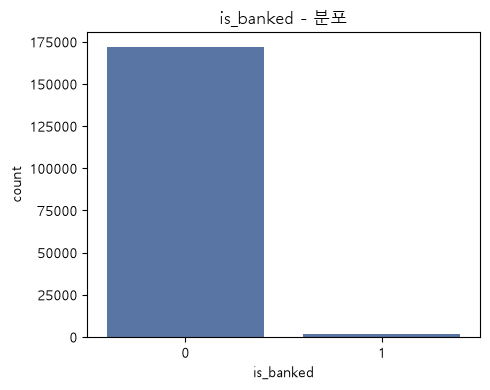

is_banked
0    172003
1      1909
Name: count, dtype: int64

In [13]:
# 1-1 countplot (is_banked)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='is_banked', color='#4C72B0', ax=ax)
ax.set_title('is_banked - 분포')
plt.tight_layout()
plt.show()

df['is_banked'].value_counts()

# ? is_banked=1(이월 결과)이 전체의 1.1%뿐인데, 이 학생들은 실제로 이번 학기에 응시하지 않은 것 아닐까?

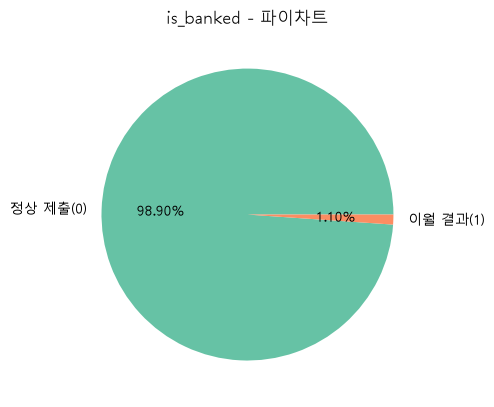

In [14]:
# 1-2 파이차트 (is_banked)

fig, ax = plt.subplots(figsize=(5, 5))
counts = df['is_banked'].value_counts()
ax.pie(counts, labels=['정상 제출(0)', '이월 결과(1)'], autopct='%1.2f%%',
       colors=sns.color_palette('Set2', 2))
ax.set_title('is_banked - 파이차트')
plt.tight_layout()
plt.show()

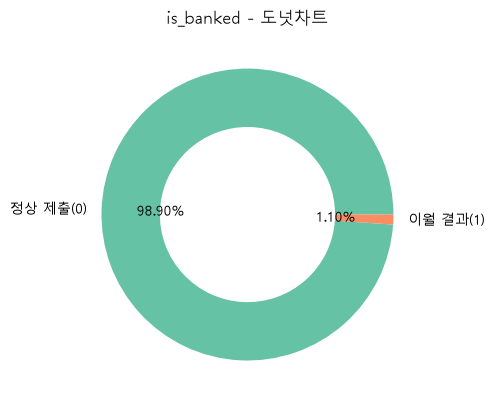

In [15]:
# 1-3 도넛차트 (is_banked)

fig, ax = plt.subplots(figsize=(5, 5))
counts = df['is_banked'].value_counts()
ax.pie(counts, labels=['정상 제출(0)', '이월 결과(1)'], autopct='%1.2f%%',
       colors=sns.color_palette('Set2', 2), wedgeprops={'width': 0.4})
ax.set_title('is_banked - 도넛차트')
plt.tight_layout()
plt.show()

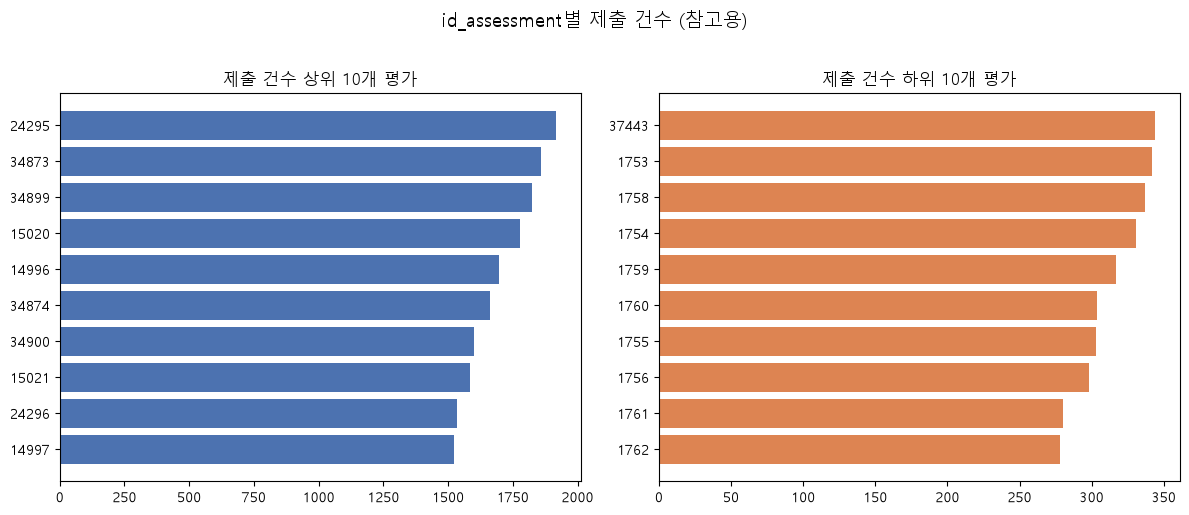

In [16]:
# 1-4 참고: id_assessment별 제출 건수 상위/하위 10개 (식별자 아님, 그룹변수로만 참고)

vc = df['id_assessment'].value_counts()
top10, bottom10 = vc.head(10), vc.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(top10.index.astype(str), top10.values, color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('제출 건수 상위 10개 평가')
axes[1].barh(bottom10.index.astype(str), bottom10.values, color='#DD8452')
axes[1].invert_yaxis()
axes[1].set_title('제출 건수 하위 10개 평가')
fig.suptitle('id_assessment별 제출 건수 (참고용)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ! 평가별 제출 건수는 278건~1,917건으로 약 7배 차이 → 과목별 수강생 규모 차이로 보이며,
#   어느 과목/학기인지는 assessments.csv와 조인해야 확인 가능

## 2. 수치형 그래프

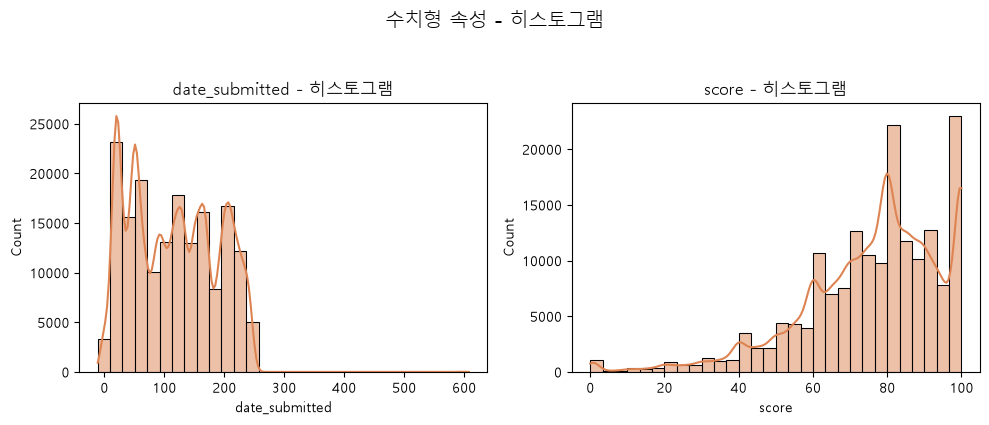

In [17]:
# 2-1 히스토그램(+KDE)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, color='#DD8452', ax=ax)
    ax.set_title(f'{col} - 히스토그램')
fig.suptitle('수치형 속성 - 히스토그램', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ? score가 특정 구간(80~90점대)에 몰려있는 이유는? 만점이 아니라 이 구간에 집중되는 이유는?

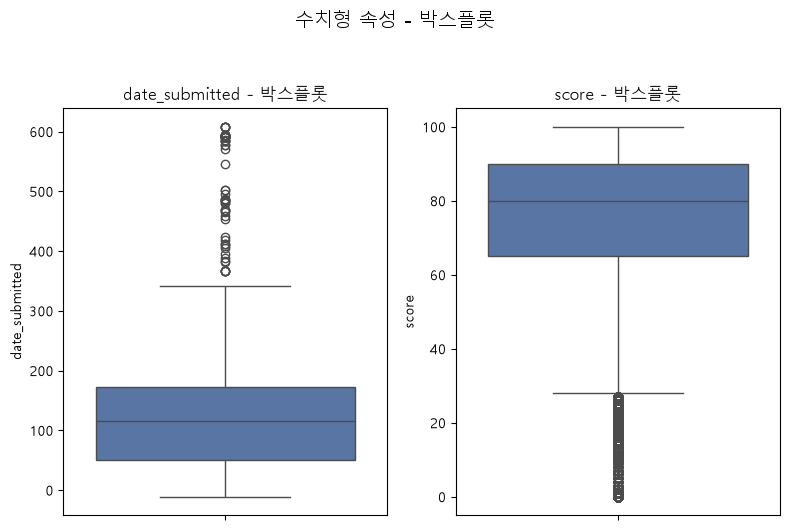

In [18]:
# 2-2 박스플롯

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, y=col, color='#4C72B0', ax=ax)
    ax.set_title(f'{col} - 박스플롯')
fig.suptitle('수치형 속성 - 박스플롯', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

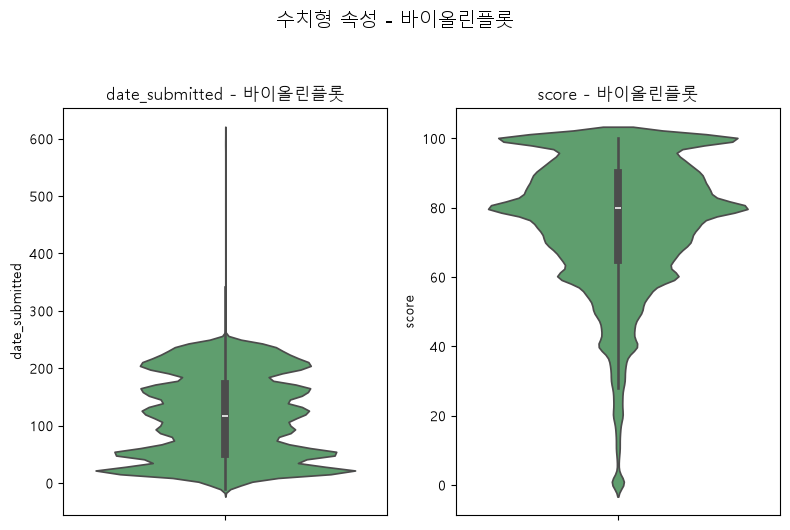

In [19]:
# 2-3 바이올린플롯

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, y=col, color='#55A868', ax=ax)
    ax.set_title(f'{col} - 바이올린플롯')
fig.suptitle('수치형 속성 - 바이올린플롯', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [20]:
# 2-4 왜도/첨도 및 이상치(IQR)

for col in num_cols:
    print(f"[{col}] skew={df[col].skew():.3f}, kurt={df[col].kurt():.3f}")
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  이상치 개수: {len(outliers)} (기준: {lower:.1f} ~ {upper:.1f})")

# score는 왼쪽 꼬리(skew<0)로 저점수 쪽에 이상치가 몰림 → 저조한 성취/포기성 제출 가능성
# date_submitted는 오른쪽 꼬리(skew>0)로 매우 늦게 제출된 건들이 이상치로 잡힘

[date_submitted] skew=0.179, kurt=-0.892
  이상치 개수: 59 (기준: -132.0 ~ 356.0)
[score] skew=-1.076, kurt=1.529
  이상치 개수: 3813 (기준: 27.5 ~ 127.5)


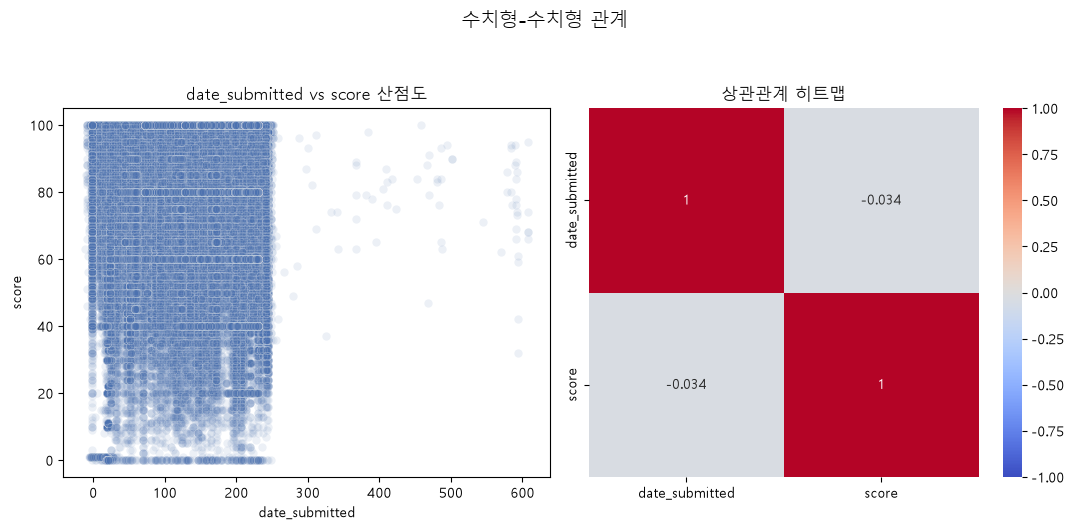

In [21]:
# 2-5 산점도, 상관관계 히트맵

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.scatterplot(data=df, x='date_submitted', y='score', alpha=0.1, color='#4C72B0', ax=axes[0])
axes[0].set_title('date_submitted vs score 산점도')

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('상관관계 히트맵')

fig.suptitle('수치형-수치형 관계', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ? 제출일이 늦을수록 점수가 낮아지는 경향이 있는가? -> 상관계수로 1차 확인, 약한 음의 상관이면 별도 검증 필요

## 3. 범주형과 수치형 종합 그래프

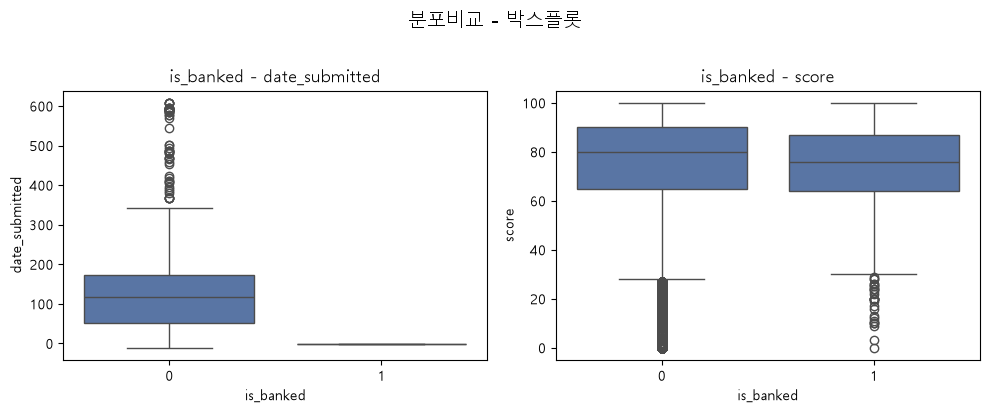

In [22]:
# 3-1 분포비교 - 박스플롯 (is_banked별)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='is_banked', y=col, color='#4C72B0', ax=ax)
    ax.set_title(f'is_banked - {col}')
fig.suptitle('분포비교 - 박스플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

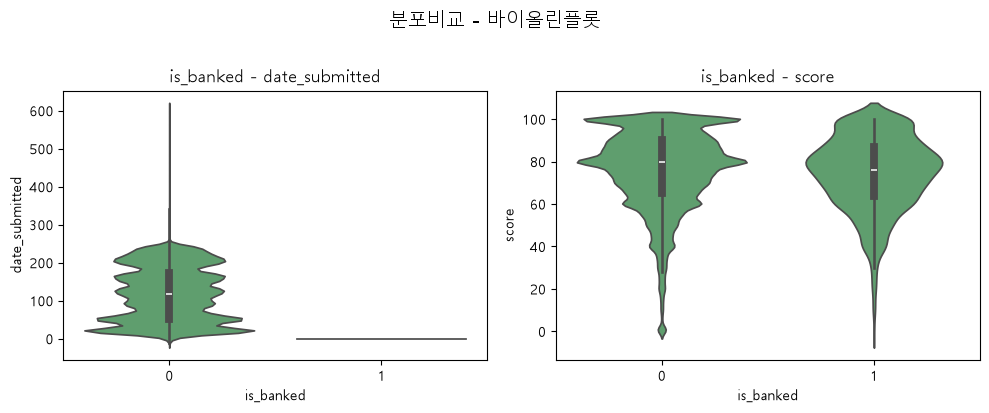

In [23]:
# 3-2 분포비교 - 바이올린플롯

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, x='is_banked', y=col, color='#55A868', ax=ax)
    ax.set_title(f'is_banked - {col}')
fig.suptitle('분포비교 - 바이올린플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

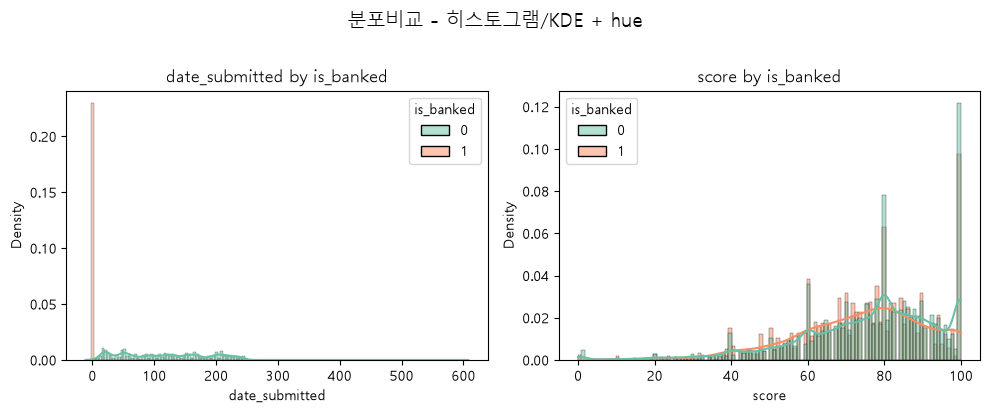

In [24]:
# 3-3 분포비교 - 히스토그램(+KDE) hue

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='is_banked', kde=True, palette='Set2', stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{col} by is_banked')
fig.suptitle('분포비교 - 히스토그램/KDE + hue', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

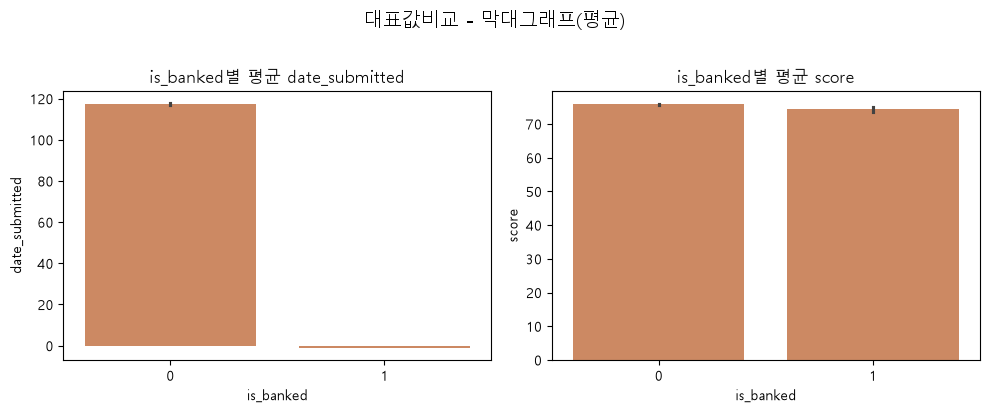

In [25]:
# 3-4 대표값 비교 - 막대그래프(평균)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.barplot(data=df, x='is_banked', y=col, color='#DD8452', ax=ax)
    ax.set_title(f'is_banked별 평균 {col}')
fig.suptitle('대표값비교 - 막대그래프(평균)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

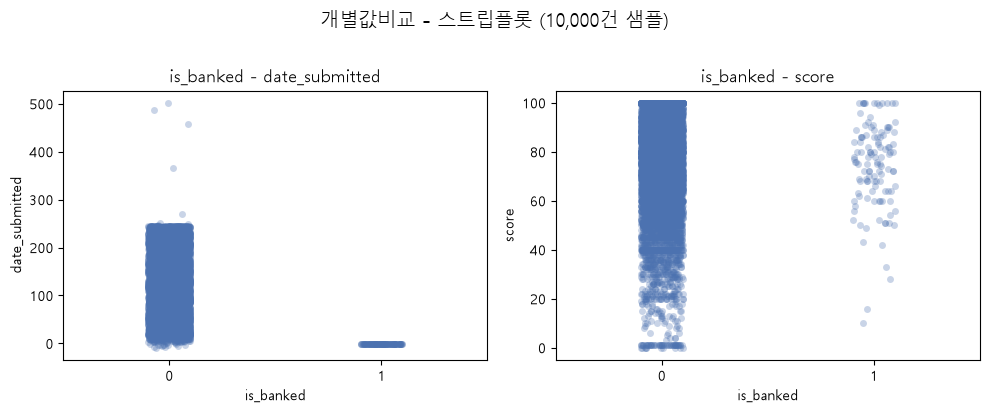

In [26]:
# 3-5 개별값 비교 - 스트립플롯 (10,000건 샘플링)
# 전체 173,912건을 그대로 찍으면 점이 겹쳐 분포를 읽기 어려워 샘플링함

sample = df.sample(10000, random_state=42)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.stripplot(data=sample, x='is_banked', y=col, color='#4C72B0', alpha=0.3, ax=ax)
    ax.set_title(f'is_banked - {col}')
fig.suptitle('개별값비교 - 스트립플롯 (10,000건 샘플)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

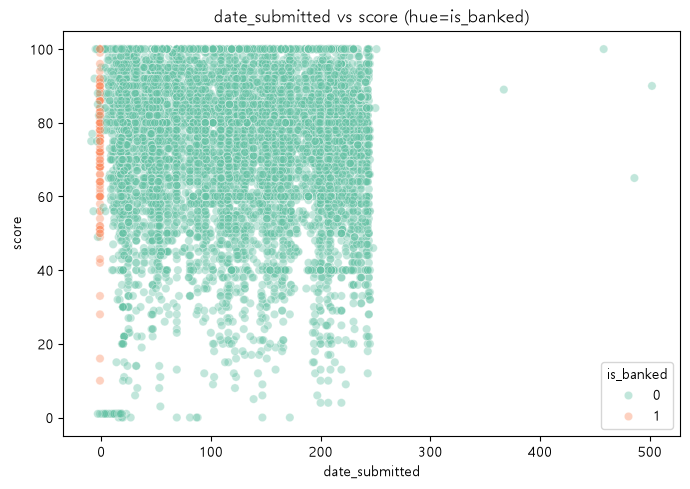

In [27]:
# 3-6 관계확인 - 산점도 + hue

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df.sample(10000, random_state=42), x='date_submitted', y='score',
                 hue='is_banked', palette='Set2', alpha=0.4, ax=ax)
ax.set_title('date_submitted vs score (hue=is_banked)')
plt.tight_layout()
plt.show()

# 3. 통계 검정이 필요한지

## 핵심 원칙
> **검정은 "질문"이 있을 때만 한다. 배웠으니까 일단 돌리는 것은 함정이다.**

앞서 assessments.csv(정의표) 단독 분석에서는 비교할 두 집단이 없어 검정이 불필요했다.
반면 studentAssessment.csv는 **조인 없이도 `is_banked`(0/1)라는 실제 두 집단이 이미 존재**한다.
"정상 제출 집단과 이월(banked) 집단의 점수가 실제로 다른가?"라는 질문이 성립하므로,
이 파일에서는 검정을 해볼 근거가 있다.

## 검정 방법 선택
- `score`의 왜도(skew)가 뚜렷한 음수(-1.08) → 정규분포 가정 어려움
- `is_banked` 두 집단의 표본 크기가 극단적으로 불균형(171,831건 vs 1,908건)
- → 정규성을 가정하는 t검정 대신, 분포 형태에 관계없이 쓸 수 있는 **Mann-Whitney U 검정**이 적절

In [28]:
from scipy import stats

# 참고: 정규성 확인 (전체를 그대로 쓰면 n이 너무 커서 왜곡되므로 5,000건 샘플)
sample_score = df['score'].dropna().sample(5000, random_state=42)
stat, p = stats.shapiro(sample_score)
print(f'Shapiro-Wilk: stat={stat:.4f}, p={p:.4g}')

# is_banked=0(정상) vs 1(이월) 그룹간 score 비교
g0 = df[df['is_banked'] == 0]['score'].dropna()
g1 = df[df['is_banked'] == 1]['score'].dropna()

u_stat, u_p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
print(f'Mann-Whitney U: stat={u_stat:.1f}, p={u_p:.4g}')
print('정상(0) median:', g0.median(), ' 이월(1) median:', g1.median())
print('정상(0) mean:', round(g0.mean(), 2), ' 이월(1) mean:', round(g1.mean(), 2))

Shapiro-Wilk: stat=0.9245, p=1.342e-44
Mann-Whitney U: stat=175643982.5, p=7.322e-08
정상(0) median: 80.0  이월(1) median: 76.0
정상(0) mean: 75.82  이월(1) mean: 74.35


## 결과 해석
- Shapiro-Wilk 결과 p<0.001 → `score`는 정규분포가 아님 (히스토그램에서 본 좌측 치우침과 일치)
- Mann-Whitney U 검정 결과 p ≈ 7.3e-08(<0.05) → 정상 제출 집단과 이월 집단의 점수 분포는
  **통계적으로 유의하게 다름**(중앙값 80 vs 76)
- 다만 표본이 17만 건이 넘어 아주 작은 차이도 유의하게 나오기 쉽다는 점(표본 크기 효과)은 감안해야 한다.
  중앙값 차이가 4점 정도로 크지 않아 실질적 의미는 크지 않을 수 있다.
- 이 결과 자체보다 중요한 시사점은 따로 있다: `is_banked=1`은 사실상 "이번 학기에 실제로 응시하지 않은" 케이스에
  가깝다. 뒤의 4번 섹션에서 이 점이 이탈률 집계에 왜 혼선을 주는지 다룬다.

# 4. 단독으로 확인할 수 있는 이탈률과 연관된 것들(검증은 조인)

## Q1. 학생별 제출 횟수(참여도)가 극단적으로 적으면 조기 이탈 후보일까?

### 과정

count    23369.000000
mean         7.441996
std          4.223937
min          1.000000
25%          4.000000
50%          7.000000
75%         11.000000
max         28.000000
Name: count, dtype: float64


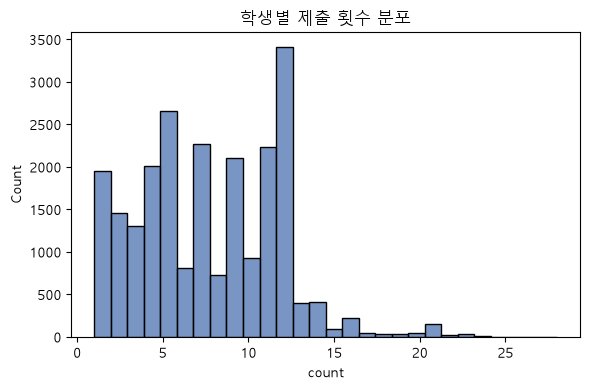

제출 2건 이하 학생 수: 3413명 (14.60%)


In [29]:
# 근거 : 2-3 고유값 개수 (id_student 23,369명, 1인당 1~28건)

vc_student = df['id_student'].value_counts()
print(vc_student.describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(vc_student, bins=28, color='#4C72B0', ax=ax)
ax.set_title('학생별 제출 횟수 분포')
plt.tight_layout()
plt.show()

low_participation = (vc_student <= 2).sum()
print(f'제출 2건 이하 학생 수: {low_participation}명 ({low_participation/len(vc_student):.2%})')

### 설명

학생별 제출 횟수는 평균 7.4건이지만 최소 1건인 학생도 있다. 제출을 1~2건만 한 학생이 적지 않은 비중을
차지하는데, 이는 초반에 학습을 그만뒀을 가능성을 시사한다. 다만 이 값만으로는 "적게 냈다"와
"실제로 이탈했다"를 동일시할 수 없다 — 애초에 그 학생이 등록한 과목의 평가 개수 자체가 적을 수도 있기
때문이다. 실제 이탈 여부는 `studentInfo.csv`의 `final_result`, `studentRegistration.csv`의
`date_unregistration`과 조인해야 검증할 수 있다.

## Q2. 0점(score=0) 제출은 이탈의 전조일까?

### 과정

score=0 건수: 329 (0.189%)
count    329.000000
mean     113.191489
std       76.715958
min       -1.000000
25%       24.000000
50%      116.000000
75%      179.000000
max      248.000000
Name: date_submitted, dtype: float64


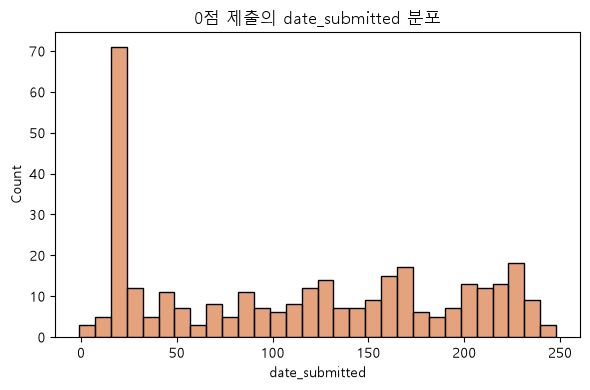

In [30]:
# 근거 : 1-3 기술통계 / 2-1 히스토그램(score 좌측 이상치)

zero_score = df[df['score'] == 0]
print('score=0 건수:', len(zero_score), f'({len(zero_score)/len(df):.3%})')
print(zero_score['date_submitted'].describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(zero_score['date_submitted'], bins=30, color='#DD8452', ax=ax)
ax.set_title('0점 제출의 date_submitted 분포')
plt.tight_layout()
plt.show()

### 설명

0점 제출은 329건(전체의 0.19%)으로 매우 드물다. 제출 시점은 -1일부터 248일까지 넓게 퍼져 있어
특정 구간(학기 초반/후반)에 몰려있는 뚜렷한 패턴은 보이지 않는다. 0점이 이탈의 신호인지, 단순히
어려운 문제를 못 풀어 0점을 받은 것인지는 이 파일만으로 구분할 수 없다. 이 학생들이 이후 다른
평가도 계속 제출했는지, 아니면 여기서 멈췄는지를 봐야 하며 → `studentInfo.csv`, 그리고 학생별
제출 이력의 시계열(=이 파일 내 id_student 그룹핑)을 함께 봐야 확정할 수 있다.

## Q3. 결측치(score 없음, 173건)는 이탈과 관련이 있을까?

### 과정

In [31]:
# 근거 : 1-4 결측치 위치 조회

na_score = df[df['score'].isna()]
print('score 결측 건수:', len(na_score))
print(na_score['is_banked'].value_counts())
print(na_score['date_submitted'].describe())

score 결측 건수: 173
is_banked
0    172
1      1
Name: count, dtype: int64
count    173.000000
mean     128.803468
std       75.036554
min       -2.000000
25%       54.000000
50%      129.000000
75%      203.000000
max      274.000000
Name: date_submitted, dtype: float64


### 설명

결측 173건 중 172건이 `is_banked=0`(정상 제출)이다. 즉 제출 자체는 기록됐는데 점수만 비어있는
경우로, 채점 지연이나 시스템상의 누락일 가능성이 크다. 만약 실제로는 제출하지 않았는데 제출 기록만
남은 오류라면 이는 사실상 미제출(이탈 신호)로 재분류해야 한다. 어느 쪽인지는 이 파일만으로 판단할
수 없고, `assessments.csv`(해당 평가의 weight·마감일)와 `studentRegistration.csv`(등록 상태)를
함께 봐야 한다.

## Q4. is_banked(이월 결과)가 이탈률 집계에 혼선을 줄 수 있을까?

### 과정

In [32]:
# 근거 : 2-3 고유값 개수 / 3장 검정 결과

print(df['is_banked'].value_counts())
print()
print('음수 date_submitted 중 is_banked 비중')
print(pd.crosstab(df['date_submitted'] < 0, df['is_banked']))

is_banked
0    172003
1      1909
Name: count, dtype: int64

음수 date_submitted 중 is_banked 비중
is_banked            0     1
date_submitted              
False           171855     0
True               148  1909


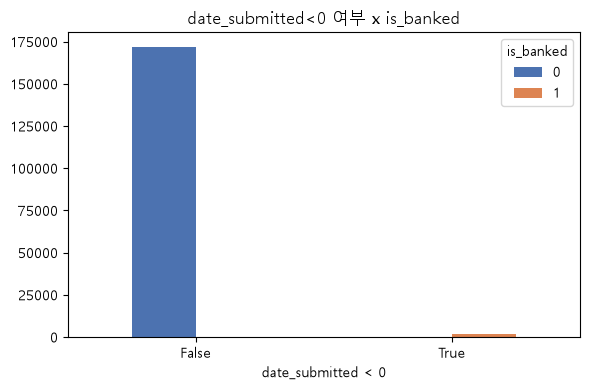

In [33]:
# Q4 보강: 음수 제출일 여부 x is_banked 시각화

fig, ax = plt.subplots(figsize=(6, 4))
pd.crosstab(df['date_submitted'] < 0, df['is_banked']).plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('date_submitted<0 여부 x is_banked')
ax.set_xlabel('date_submitted < 0')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ! date_submitted<0(음수)인 건 거의 전부 is_banked=1과 겹친다는 게 그래프로도 뚜렷하게 보임

### 설명

`is_banked=1`은 1,909건(1.1%)으로, 이전 학기 점수가 그대로 이월된 경우다. 흥미로운 점은 음수
`date_submitted`(2,057건) 중 1,909건이 `is_banked=1`과 겹친다는 것이다 — 즉 "마감일 이전에
조기 제출"한 게 아니라, 이월 데이터 특유의 표기 방식(예: 이전 학기 제출일을 그대로 옮기며 음수로
찍힘)일 가능성이 크다. 이 학생들은 이번 학기에 실제로 응시하지 않았을 수 있는데, 단순히 "제출
건수"만 세면 참여한 것으로 잘못 집계되어 이탈률을 과소평가하게 만들 위험이 있다. 실제 등록 상태
확인은 `studentRegistration.csv` 조인이 필요하다.

## Q5. 제출일(date_submitted) 음수값은 이례적인 조기 제출일까?

### 과정

In [34]:
# 근거 : 1-3 기술통계 / Q4에서 확인한 is_banked와의 관계

early = df[df['date_submitted'] < 0]
print('제출일 음수 건수:', len(early), f'({len(early)/len(df):.3%})')
print(early['is_banked'].value_counts())
print(early['date_submitted'].describe())

제출일 음수 건수: 2057 (1.183%)
is_banked
1    1909
0     148
Name: count, dtype: int64
count    2057.000000
mean       -1.249392
std         1.142788
min       -11.000000
25%        -1.000000
50%        -1.000000
75%        -1.000000
max        -1.000000
Name: date_submitted, dtype: float64


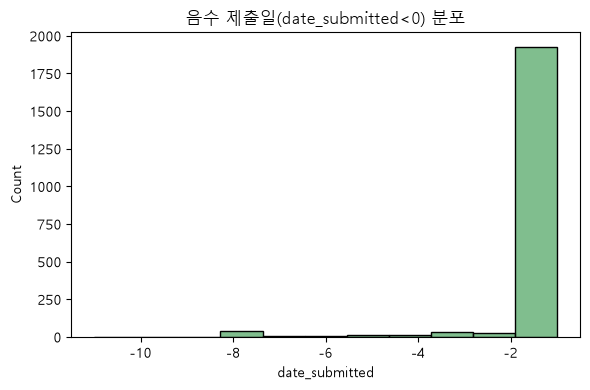

In [35]:
# Q5 보강: 음수 제출일(date_submitted<0)의 분포 시각화

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(early['date_submitted'], bins=11, color='#55A868', ax=ax)
ax.set_title('음수 제출일(date_submitted<0) 분포')
plt.tight_layout()
plt.show()

### 설명

음수 제출일은 전체의 1.2%(2,057건)이며, Q4에서 확인했듯 대부분(1,909건)이 `is_banked=1`과
겹친다. 나머지 148건만 순수하게 `is_banked=0`이면서 음수인 케이스로, 이 소수만이 진짜 "학기 시작
전 조기 제출"에 해당할 가능성이 있다. 이 148건이 실제로 어떤 과목·학기의 평가인지, 조기 제출이
이탈과 관련 있는지는 `assessments.csv`와 조인해 마감일 기준으로 다시 계산해봐야 한다.

# 5. 다른 CSV 파일과 연관지어야 확인할 수 있는 것들

## 질문

- `id_assessment`를 `assessments.csv`와 조인하면 마감일(`date`)과 실제 제출일(`date_submitted`)의
  차이(지각 일수)를 계산할 수 있다. 어떤 과목·평가 유형에서 지각이 잦은지, 지각이 이탈로 이어지는지
  확인 가능하다.
- `id_student`를 `studentInfo.csv`와 조인하면 최종 결과(`final_result`: Withdrawn/Fail/Pass/
  Distinction)별로 제출 횟수·평균 점수·0점 비율이 다른지 확인할 수 있다. Q1(저조한 참여)과
  Q2(0점 제출)가 실제 이탈로 이어졌는지 검증하는 핵심 조인이다.
- `id_student`를 `studentRegistration.csv`와 조인하면 등록취소일(`date_unregistration`)과 마지막
  제출일 사이의 간격을 계산해, "제출을 멈춘 뒤 실제로 등록을 취소하기까지 얼마나 걸리는지"를 파악할
  수 있다. Q4(is_banked 혼선)도 실제 등록 상태를 확인하면 해소된다.
- `id_student`를 `studentVle.csv`와 조인하면 학습활동(로그인·클릭) 감소 시점과 과제 제출 중단·점수
  하락 시점이 실제로 맞물리는지 확인할 수 있다.
- `id_assessment`를 `assessments.csv`와 조인해 비중(`weight`)이 큰 평가(예: Exam)에서 미제출·저점수가
  발생했을 때, 비중이 작은 평가에서 그런 경우보다 이탈에 미치는 영향이 더 큰지 비교할 수 있다.
- 이 파일에서 이탈과 직접 무관해 보이는 속성: `id_assessment`/`id_student` 자체(식별 목적), 그리고
  `date_submitted`의 절대값(마감일과 비교하기 전까지는 "언제 냈는지"만 알 뿐 "늦었는지"는 알 수 없어
  의미가 약함).